In [71]:
import pandas as pd
from yeast_analysis.pathway_shorthands import pathway_shorthands


In [4]:
df_pwyx = pd.read_csv('results/pwyx.csv', index_col=0)

In [9]:
df_pwyx.vc.sum()

np.float64(0.010631771944018646)

In [11]:
df_pwyx['vc_renormed'] = df_pwyx.vc/df_pwyx.vc.sum()

In [34]:
df_pwyx = df_pwyx.sort_values(by='vc_mean', ascending=False)

In [86]:
import importlib
import yeast_analysis.pathway_crosstalk
importlib.reload(yeast_analysis.pathway_crosstalk)

from yeast_analysis.pathway_crosstalk import pathway_hub_subnetwork, plot_pathway_subnetwork, plot_top_interaction_network

In [36]:
df_pwyx.head()

,pwy1,pwy2,vc,vc_mean,vc_renormed
24,PWY3O-19,PWY3O-450,0.000003,9.351415e-09,0.000296
2914,PWY-6614,PWY3O-50,0.000002,8.528343e-09,0.000154
5,PWY3O-19,PWY3O-48,0.000002,8.266930e-09,0.000229
394,PWY3O-862,PWY3O-450,0.000003,6.507800e-09,0.000313
53,PWY3O-19,PWY0-662,0.000005,6.040369e-09,0.000501


In [76]:
df_pwyx.pwy1 = df_pwyx.pwy1.replace(pathway_shorthands)
df_pwyx.pwy2 = df_pwyx.pwy2.replace(pathway_shorthands)

In [42]:
# G, hub_scores, edge_table, info = pathway_hub_subnetwork(
#     df_pwyx,
#     weight="vc_mean",
#     strong_edge_quantile=0.90,
#     hub_metric="hybrid",
#     n_hubs=20,
#     neighbor_edge_quantile=0.99,
#     top_k_per_hub=6,
# )

# fig, ax, pos = plot_pathway_subnetwork(
#     G,
#     weight="vc_mean",
#     layout="spring",
#     k=0.75,
# )

In [55]:
k = 100
top_edges = df_pwyx.nlargest(k, "vc_mean")
weights = list(df_pwyx["vc_mean"].iloc[:k])

In [56]:
import networkx as nx

G = nx.from_pandas_edgelist(
    top_edges,
    source="pwy1",
    target="pwy2",
    edge_attr="vc_mean",
    create_using=nx.Graph(),
)

In [85]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# k = 10

# # Top k strongest interactions
# top_edges = df_pwyx.nlargest(k, "vc_mean")

# # Build graph
# G = nx.from_pandas_edgelist(
#     top_edges,
#     source="pwy1",
#     target="pwy2",
#     edge_attr="vc_mean",
#     create_using=nx.Graph()
# )

# # Top 5 nodes by degree
# hubs = [
#     n for n, d in sorted(
#         G.degree,
#         key=lambda x: x[1],
#         reverse=True
#     )[:2]
# ]

# rng = np.random.default_rng(1)

# # Initial random positions
# pos0 = {
#     n: rng.uniform(-1, 1, size=2)
#     for n in G.nodes
# }

# # Put hubs close to the origin initially
# for n in hubs:
#     pos0[n] = rng.normal(0, 0.05, size=2)

# pos = nx.spring_layout(
#     G,
#     pos=pos0,
#     seed=1,
#     weight="vc_mean",
#     k=0.1,
#     iterations=300
# )

# # Get edge weights in exactly the same order as G.edges()
# weights = np.array([
#     G[u][v]["vc_mean"]
#     for u, v in G.edges()
# ])

# # Scale weights to reasonable line widths
# widths = 0.5 + 4 * (
#     (weights - weights.min()) /
#     (weights.max() - weights.min())
# )

# plt.figure(figsize=(8, 8))

# nx.draw_networkx_nodes(
#     G,
#     pos,
#     node_size=0,
# )

# nx.draw_networkx_edges(
#     G,
#     pos,
#     width=widths,
#     alpha=0.6,
# )

# nx.draw_networkx_labels(
#     G,
#     pos,
#     font_size=10,
# )

# plt.axis("off")
# plt.tight_layout()
# plt.show()

10 nodes, 10 edges
Hubs: ['Ubiquinol-6 synth. (4-HB)']
Edge crossings: 1


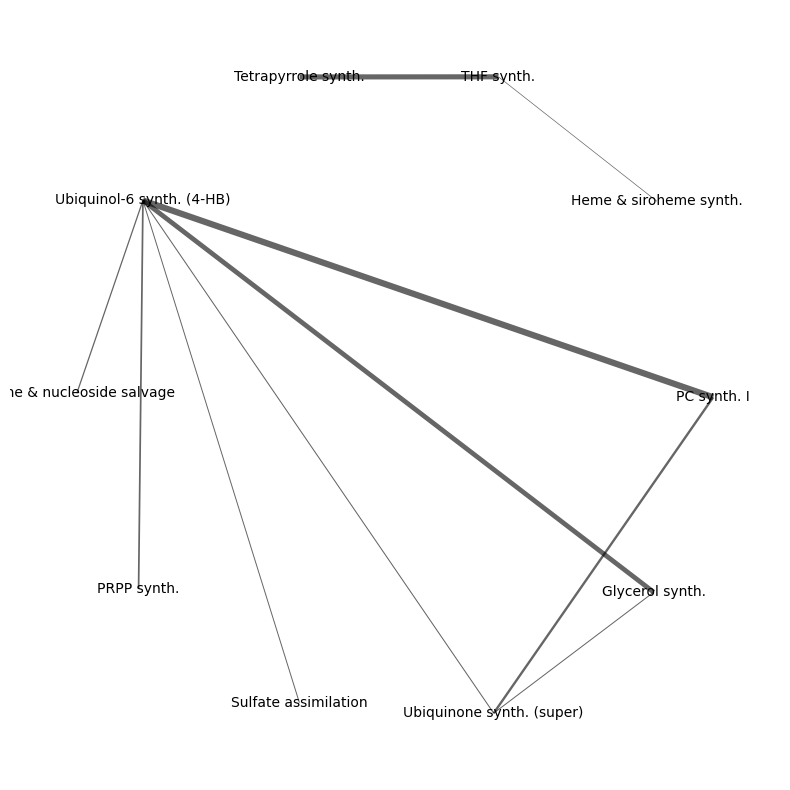

In [92]:
G, pos, hubs, top_edges = plot_top_interaction_network(
    df_pwyx,
    k=10,
    n_hubs=1,
    hub_metric="degree",
    spring_k=2,
    n_layout_trials=100,
)